First 5 rows:
  Order ID  Order Date CustomerName           State       City
0  B-25601  01-04-2018       Bharat         Gujarat  Ahmedabad
1  B-25602  01-04-2018        Pearl     Maharashtra       Pune
2  B-25603  03-04-2018        Jahan  Madhya Pradesh     Bhopal
3  B-25604  03-04-2018       Divsha       Rajasthan     Jaipur
4  B-25605  05-04-2018      Kasheen     West Bengal    Kolkata

Dataset Shape: (560, 5)

Columns:
['Order ID', 'Order Date', 'CustomerName', 'State', 'City']

Target Distribution:
State_Class
0    470
1     90
Name: count, dtype: int64

Training Samples: 448
Testing Samples: 112

Best Parameters:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

Best Cross-Validation Accuracy: 100.0 %

SVM Test Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

 Other State       1.00      1.00      1.00        94
 Maharashtra       1.00      1.00      1.00        18

    accuracy                           1.00       112
  

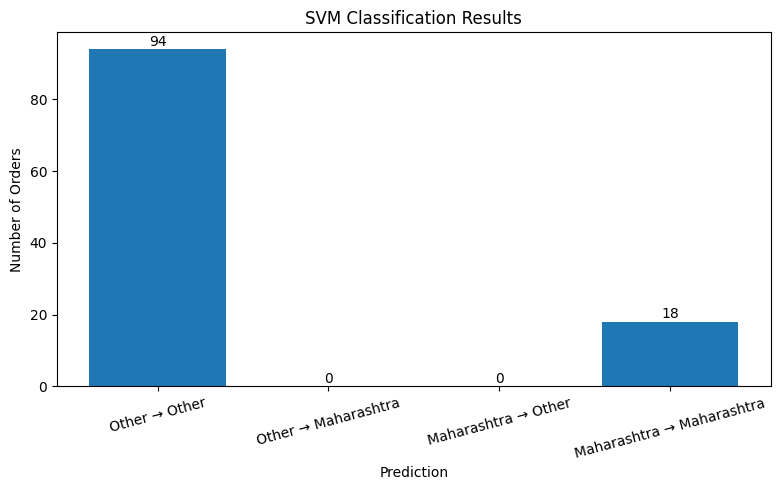

In [2]:
# PRACTICAL 3: SUPPORT VECTOR MACHINE (SVM)
# Dataset: List of Orders (1).csv

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
df = pd.read_csv("List of Orders (1).csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# Convert Order Date
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)

df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["Weekday"] = df["Order Date"].dt.weekday

# Create Binary Target
df["State_Class"] = (
    df["State"]
    .fillna("")
    .str.strip()
    .str.lower()
    .eq("maharashtra")
    .astype(int)
)

print("\nTarget Distribution:")
print(df["State_Class"].value_counts())

# Select Features and Target
X = df[["City", "Month", "Day", "Weekday"]]
y = df["State_Class"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# Preprocessing
categorical_features = ["City"]
numeric_features = ["Month", "Day", "Weekday"]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features)
])

# Create SVM Pipeline
svm_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("svm", SVC())
])

# Optimize SVM Parameters
parameters = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    svm_pipeline,
    parameters,
    cv=5,
    scoring="accuracy",
    error_score="raise"
)

grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Accuracy:",
      round(grid.best_score_ * 100, 2), "%")

# Prediction
y_pred = grid.predict(X_test)

# Evaluate SVM
accuracy = accuracy_score(y_test, y_pred)

print("\nSVM Test Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Other State", "Maharashtra"],
    zero_division=0
))

# Simple Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)

labels = [
    "Other → Other",
    "Other → Maharashtra",
    "Maharashtra → Other",
    "Maharashtra → Maharashtra"
]

values = [
    cm[0, 0],
    cm[0, 1],
    cm[1, 0],
    cm[1, 1]
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.xlabel("Prediction")
plt.ylabel("Number of Orders")
plt.title("SVM Classification Results")

plt.xticks(rotation=15)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()